In [1]:
import cafe

# cafe.logger.setLevel("DEBUG")

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

read trajectory result

In [2]:
fadata = cafe.data.read_pancrease()
del fadata.uns["neighbors"] # velocity neighbor info error, need recalculate

model_name_list = [
    # velocity
    "scvelo",
    "velovi",
    "dynamo",
    # "celldancer", # CBDir 和ICVCoh一直报错
    "pyrovelocity",
    "veloae",
    "unitvelo",
    # linear, pseudotime
    "comp1",
    "palantir",
    "cytotrace2",
    "sctc",
    # lineage
    "cellrank",
    # # cluster
    "stavia",
    #
    "ti_slingshot",
    ]
# 只初始化fadata，不预加载所有模型轨迹


# 不再预加载所有模型轨迹
# fadata.load_trajectory_dict(model_name_list=model_name_list) # 注释掉此行
# model_name_list = fadata.get_all_model_name(parse=False)
# color_list = ["clusters", "milestone"] # delete "milestone" to speed up
# color_list = ["clusters"]
# cafe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

fadata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

calculate metric

In [3]:
import os
import pandas as pd

# metrics = [
#     "pseudotime_correlation",
#     "velocity_cbdir",
#     "velocity_icvcoh",
#     "isomorphic",
#     "edge_flip",
#     "him",
#     "correlation",
#     "F1_branches",
#     "F1_milestones",
# ]
metrics = None  # calculate all metrics 
if metrics is None:
    metrics = list(cafe.metric.metrics["metric_id"])


# cbdir
# cluster_edges = {
#     ("Ductal", "Ngn3 low EP"),
#     ("Ngn3 low EP", "Ngn3 high EP"),
#     ("Ngn3 high EP", "Pre-endocrine"),
#     ("Pre-endocrine", "Alpha"),
#     ("Pre-endocrine", "Beta"),
#     ("Pre-endocrine", "Delta"),
#     ("Pre-endocrine", "Epsilon"),
# }
# extract cluster edges from milestone network for "ref" model
cluster_edges =  fadata.get_milestone_wrapper().milestone_network[["from", "to"]].values.tolist()

# load calculated metric csv file
metric_dir = f".cafe/{fadata.id}/metric/"
metric_file_list = os.listdir(metric_dir)

todo_model_name_list = []
calculated_metric_df_list = []
for model_name in model_name_list:
    metric_file = f"{model_name}.csv"
    if metric_file in metric_file_list:
        cafe.logger.info(f"metric file for model '{model_name}' already exists. read it.")
        calculated_metric_df = pd.read_csv(f"{metric_dir}/{metric_file}", index_col=0).T
        # check missing metrics
        missing_metrics = [m for m in metrics if m not in calculated_metric_df.columns or pd.isna(calculated_metric_df[m].iloc[0])]
        if missing_metrics:
            cafe.logger.info(f"model {model_name} missing metrics: {missing_metrics}, recalculating...")
            fadata.load_trajectory_dict(model_name_list=[model_name]) # load only needed model
            # only calculate missing metrics
            new_metric_df = cafe.metric.calculate_metrics(fadata, now_models=[model_name], metrics=missing_metrics, cluster_edges=cluster_edges)
            fadata.remove_trajectory_dict(model_name_list=[model_name]) # remove models after calculation to save memory
            # merge new and old results
            for m in missing_metrics:
                calculated_metric_df[m] = new_metric_df.loc[model_name, m]
            calculated_metric_df.T.to_csv(f"{metric_dir}/{model_name}.csv") # save the updated csv
        calculated_metric_df_list.append(calculated_metric_df)
    else:
        todo_model_name_list.append(model_name)

if calculated_metric_df_list:
    metric_df = pd.concat(calculated_metric_df_list)
else:
    metric_df = pd.DataFrame()

# calculate new metric
if "ref" in todo_model_name_list:
    todo_model_name_list.remove("ref")

if len(todo_model_name_list) > 0:
    cafe.logger.info(f"calculating metrics for models: {todo_model_name_list}")
    fadata.load_trajectory_dict(model_name_list=todo_model_name_list) # load only needed models
    new_metric_df = cafe.metric.calculate_metrics(fadata, now_models=todo_model_name_list, metrics=metrics, cluster_edges=cluster_edges)
    fadata.remove_trajectory_dict(model_name_list=todo_model_name_list) # remove models after calculation to save memory
    new_metric_df.apply(lambda x: x.to_csv(f"{metric_dir}/{x.name}.csv"), axis=1)
    metric_df = pd.concat([metric_df, new_metric_df])

# save summary metric
metric_df.to_csv(f"{metric_dir}/summary.csv")

metric_df

INFO     |- metric file for model 'scvelo' already exists. read it.                                                                                                                                     
INFO     |- metric file for model 'velovi' already exists. read it.                                                                                                                                     
INFO     |- metric file for model 'dynamo' already exists. read it.                                                                                                                                     
INFO     |- metric file for model 'pyrovelocity' already exists. read it.                                                                                                                               
INFO     |- metric file for model 'veloae' already exists. read it.                                                                                                                                 

,pseudotime_correlation,velocity_cbdir,velocity_icvcoh,isomorphic,edge_flip,him,correlation,F1_branches,F1_milestones,rf_mse,...,lm_nmse,lm_mse,lm_rsq,featureimp_cor,featureimp_wcor,featureimp_ks,featureimp_wilcox,harm_mean,geom_mean,arith_mean
scvelo,0.990982,0.538780,0.787854,1.0,1.000000,0.961104,0.882257,1.000000,1.000000,5.590169e-07,...,1.000000,0.000000,1.000000,1.000000,1.000000,0.990982,0.990982,0.990982,0.990982,0.990982
velovi,0.990982,0.559634,0.841524,1.0,1.000000,0.961104,0.882257,1.000000,1.000000,5.590169e-07,...,1.000000,0.000000,1.000000,1.000000,1.000000,0.990982,0.990982,0.990982,0.990982,0.990982
dynamo,0.076220,0.528763,0.771394,0.0,0.500000,0.560073,0.778714,0.775247,0.940568,3.361288e-03,...,0.955348,0.003558,0.944326,0.989063,0.974423,0.076220,0.076220,0.076220,0.076220,0.076220
pyrovelocity,0.829917,0.143506,0.568153,0.0,0.750000,0.527937,0.838167,0.801445,0.944028,6.094838e-04,...,0.977409,0.001800,0.941813,0.990999,0.979153,0.829917,0.829917,0.829917,0.829917,0.829917
veloae,-0.032172,-0.180327,0.835821,0.0,0.500000,0.573619,0.789336,0.923097,0.931739,9.456089e-04,...,0.971546,0.002268,0.943841,0.993442,0.986217,-0.032172,-0.032172,-0.032172,-0.032172,-0.032172
unitvelo,0.691954,0.490385,0.904033,0.0,0.500000,0.341345,0.799183,0.714663,0.920024,1.493186e-03,...,0.965808,0.002725,0.922752,0.989533,0.975914,0.691954,0.691954,0.691954,0.691954,0.691954
comp1,0.900484,0.355833,0.999772,0.0,0.000000,0.267002,NaN,0.189011,0.281500,4.449221e-02,...,0.220615,0.062110,0.178980,0.607160,0.531060,0.531060,0.531060,0.281500,0.281500,0.281500
palantir,0.981632,0.374211,0.999796,0.0,0.000000,0.267002,0.674271,0.189011,0.271796,3.283003e-02,...,0.202695,0.063539,0.158187,0.675403,0.628565,0.981632,0.981632,0.981632,0.981632,0.981632
cytotrace2,0.740008,0.310723,0.999695,0.0,0.000000,0.267002,0.096048,0.189011,0.282081,7.275653e-02,...,0.187629,0.064739,0.140749,0.490255,0.285791,0.740008,0.740008,0.740008,0.740008,0.740008
sctc,-0.030390,-0.356898,0.999719,0.0,0.000000,0.267002,0.000000,0.189011,0.284392,5.394986e-02,...,0.225782,0.061699,0.178861,0.593437,0.506999,-0.030390,-0.030390,-0.030390,-0.030390,-0.030390


benchmark visualization

In [ ]:
import numpy as np
import pandas as pd

if_normalize_metric = True
if if_normalize_metric:
    metric_meta_df = cafe.metric.metrics.set_index("metric_id")
    # normalize the metrics
    metric_df_normalized = pd.DataFrame()
    for metric_name in metric_df.columns:
        if metric_name not in metric_meta_df.index:
            print(f"Warning: metric '{metric_name}' not found in metric metadata, skipping normalization.")
            metric_df_normalized[metric_name] = metric_df[metric_name]
            continue
            
        perfect = metric_meta_df.loc[metric_name, "perfect"]
        worst = metric_meta_df.loc[metric_name, "worst"]
        metric_normalized = metric_df[metric_name]
        if metric_df[metric_name].isna().any():
            impute_value = (worst+perfect)/2
            print(f"impute value: '{impute_value}' for NaN shown in metric '{metric_name}'")
            metric_normalized = metric_normalized.fillna(impute_value) # fillna with mid value
        metric_normalized = (metric_normalized-worst)/(perfect - worst)
        metric_df_normalized[metric_name] = metric_normalized
    benchmark_df = metric_df_normalized
else:
    benchmark_df = metric_df

prior_information_df = pd.read_csv("prior_information.csv", index_col=0) # for latter prior information addition

# add benchmark info        
def add_benchmark_info(row):
    model_name = row.name
    fadata.load_trajectory_dict(model_name_list=[model_name])
    
    row["id"] = cafe.util.parse_random_time_string(model_name)
    
    # wrapper type, 
    # TODO: for dynverse backend wrapper
    row["type"] = fadata.get_raw_wrapper_dict(model_name).get("wrapper_type", "unknown").capitalize()
    
    # prior information
    row["prior_level"] = prior_information_df.loc[model_name, "level"] if model_name in prior_information_df.index else "unknown"
    
    # resource usage
    resource_usage = fadata.get_resource_usage(model_name)
    time = resource_usage.get("time", 0)
    if time < 60:
        time_text = f"{time:.0f}s"
    elif time < 3600:
        time_text = f"{time/60:.0f}min"
    else:
        time_text = f"{time/3600:.0f}h"
    row["time"] = time # for color
    row["time_text"] = time_text # for text
    
    memory = resource_usage.get("memory", 0)
    if memory < 1024:
        memory_text = f"{memory:.0f}M"
    else:
        memory_text = f"{memory/1024:.0f}G"
    row["memory"] = memory
    row["memory_text"] = memory_text

    # overall score
    target_metrics = [
        "pseudotime_correlation",
        "velocity_cbdir",
        "him",
        "F1_branches",
    ]
    valid_list = []
    for metric in target_metrics:
        if metric in row and pd.notnull(row[metric]):
            valid_list.append(row[metric])
            
    if valid_list:
        row["overall"] = np.prod(valid_list)**(1/len(valid_list))
    else:
        row["overall"] = 0
    fadata.remove_trajectory_dict(model_name_list=[model_name]) # remove models after extraction to save memory
        
    return row

benchmark_df = benchmark_df.apply(add_benchmark_info, axis=1).round(3)

# # tmp fix for scvelo and palantir
# if len(benchmark_df) > 0:
#     # Check if index exists before setting
#     if len(benchmark_df) >= 1:
#         benchmark_df.iloc[0, benchmark_df.columns.get_loc("type")] = "Velocity"
#     if len(benchmark_df) >= 2:
#         benchmark_df.iloc[1, benchmark_df.columns.get_loc("type")] = "Linear"
        
benchmark_df.to_csv(f"{fadata.id}_benchmark_df.csv")
    
benchmark_df

impute value: '0.5' for NaN shown in metric 'correlation'


,pseudotime_correlation,velocity_cbdir,velocity_icvcoh,isomorphic,edge_flip,him,correlation,F1_branches,F1_milestones,rf_mse,...,geom_mean,arith_mean,id,type,prior_level,time,time_text,memory,memory_text,overall
scvelo,0.995,0.769,0.894,1.0,1.000,0.961,0.882,1.000,1.000,1.000,...,0.991,0.991,scvelo,Velocity,free,14.000,14s,920.62,921M,0.926
velovi,0.995,0.780,0.921,1.0,1.000,0.961,0.882,1.000,1.000,1.000,...,0.991,0.991,velovi,Velocity,free,331.190,6min,2329.13,2G,0.929
dynamo,0.538,0.764,0.886,0.0,0.500,0.560,0.779,0.775,0.941,0.989,...,0.076,0.076,dynamo,Velocity,strong restricted,125.330,2min,5503.20,5G,0.650
pyrovelocity,0.915,0.572,0.784,0.0,0.750,0.528,0.838,0.801,0.944,0.998,...,0.830,0.830,pyrovelocity,Velocity,free,672.870,11min,14051.57,14G,0.686
veloae,0.484,0.410,0.918,0.0,0.500,0.574,0.789,0.923,0.932,0.997,...,-0.032,-0.032,veloae,Velocity,free,37.120,37s,2283.07,2G,0.569
unitvelo,0.846,0.745,0.952,0.0,0.500,0.341,0.799,0.715,0.920,0.995,...,0.692,0.692,unitvelo,Velocity,strong restricted,482.830,8min,3624.93,4G,0.626
comp1,0.950,0.678,1.000,0.0,0.000,0.267,0.500,0.189,0.281,0.852,...,0.281,0.281,comp1,Linear,weakly restricted,0.000,0s,0.00,0M,0.425
palantir,0.991,0.687,1.000,0.0,0.000,0.267,0.674,0.189,0.272,0.891,...,0.982,0.982,palantir,Linear,strong restricted,0.000,0s,0.00,0M,0.431
cytotrace2,0.870,0.655,1.000,0.0,0.000,0.267,0.096,0.189,0.282,0.757,...,0.740,0.740,cytotrace2,Linear,weakly restricted,0.000,0s,0.00,0M,0.412
sctc,0.485,0.322,1.000,0.0,0.000,0.267,0.000,0.189,0.284,0.820,...,-0.030,-0.030,sctc,Linear,free,0.000,0s,0.00,0M,0.298


No legends were provided, trying to automatically infer legends.
Some palettes were not used in the column info, adding legends for them:palette1, palette2, white6black4, palette3
Legend {'title': 'palette1', 'palette': 'palette1', 'enabled': True} did not contain a geom, inferring from the column_info.
Legend {'title': 'palette1', 'palette': 'palette1', 'enabled': True, 'geom': 'funkyrect'} did not contain labels, inferring from the geom.
Legend {'title': 'palette1', 'palette': 'palette1', 'enabled': True, 'geom': 'funkyrect', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1']} did not contain size, inferring from the labels.
Legend {'title': 'palette1', 'palette': 'palette1', 'enabled': True, 'geom': 'funkyrect', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1'], 'size': [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]} did not contain color, inferring from the palette.
Legend {'title': 'palette

<Figure size 3200x2400 with 0 Axes>

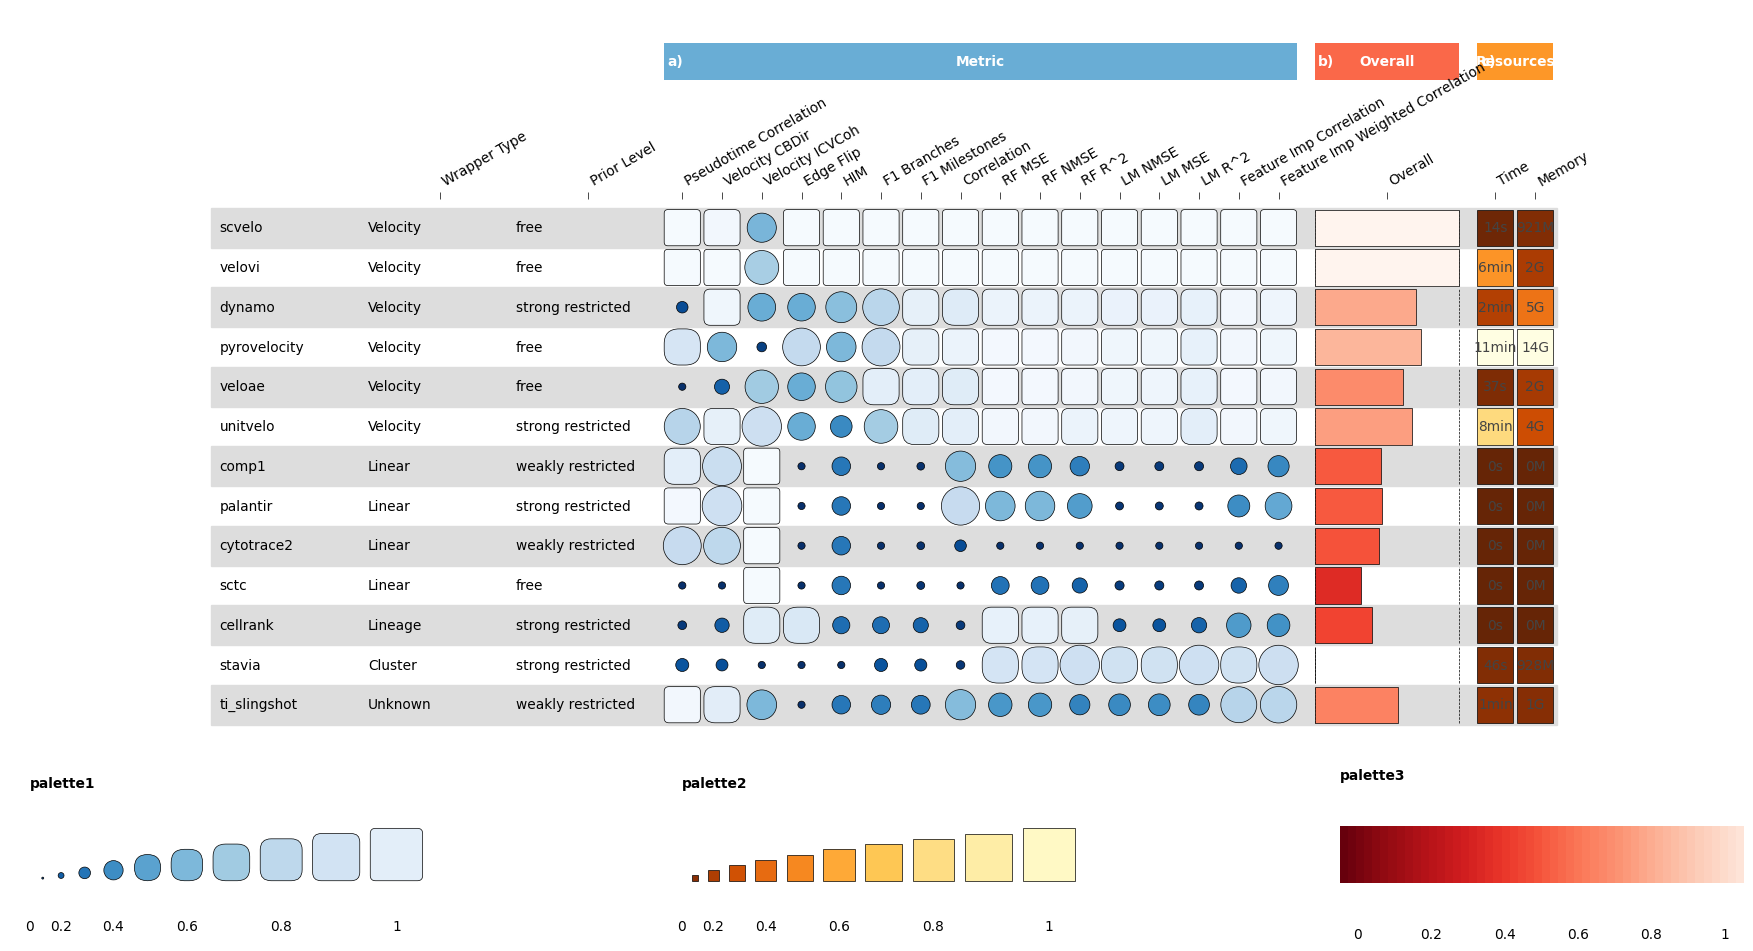

In [5]:
import matplotlib.pyplot as plt
import funkyheatmappy

plt.figure(figsize=(32, 24))

# 样式参考dynbenchmark: https://funkyheatmap.github.io/funkyheatmap/articles/dynbenchmark.html
column_list = [
    ["id", "group", "name", "geom", "options", "palette"],
    ["id", np.nan, "", "text", {"ha": 0, "width": 4}, np.nan],
    ["type", np.nan, "Wrapper Type", "text", {"ha": 0, "width": 4}, np.nan],
    ["prior_level", np.nan, "Prior Level", "text", {"ha": 0, "width": 4}, np.nan],
]

if "overall" in benchmark_df.columns:
    column_list.append(["overall", "overall", "Overall", "bar", {"width": 4, "legend": False}, "palette3"])

# resource group
if "time" in benchmark_df.columns:
    column_list.append(["time", "group2", "Time", "rect", "scaling", "palette2"])
    column_list.append(["time_text", "group2", "", "text", {"overlay": True, "size": 3, "scale": False}, "white6black4"])

if "memory" in benchmark_df.columns:
    column_list.append(["memory", "group2", "Memory", "rect", "scaling", "palette2"])
    column_list.append(["memory_text", "group2", "", "text", {"overlay": True, "size": 3, "scale": False}, "white6black4"])

id2name = {
    "pseudotime_correlation": "Pseudotime Correlation",
    "velocity_cbdir": "Velocity CBDir",
    "velocity_icvcoh": "Velocity ICVCoh",
    "edge_flip": "Edge Flip",
    "him": "HIM",
    # "isomorphic": "Isomorphic",
    "F1_branches": "F1 Branches",
    "F1_milestones": "F1 Milestones",
    "correlation": "Correlation",
    "rf_mse": "RF MSE",
    "rf_nmse": "RF NMSE",
    "rf_rsq": "RF R^2",
    "lm_nmse": "LM NMSE",
    "lm_mse": "LM MSE",
    "lm_rsq": "LM R^2",
    "featureimp_cor": "Feature Imp Correlation",
    "featureimp_wcor": "Feature Imp Weighted Correlation",
}

metric_column_list = []
for id, name in id2name.items():
    if id in benchmark_df.columns:
        metric_column_list.append([id, "group1", name, "funkyrect", "options", "palette1"])
column_list = column_list[:4] + metric_column_list + column_list[4:]

column_info = pd.DataFrame(column_list[1:], columns=column_list[0])
column_info.index = column_info["id"]

column_groups = pd.DataFrame(
    columns=["Category", "group", "palette"],
    data=[["Overall", "overall", "palette3"],
          ["Metric", "group1", "palette1"],
          ["Resources", "group2", "palette2"]]
)

if not benchmark_df.empty:
    funkyheatmappy.funky_heatmap(benchmark_df, column_info=column_info, column_groups=column_groups)
    plt.savefig("benchmark_heatmap.pdf", dpi=300)
    plt.show()
else:
    print("Benchmark DataFrame is empty, cannot plot heatmap.")